# Reproducible backtests: pin the data, not just the code

Every quant team has lived this incident. A backtest from March cannot be
reproduced in July. The code is in git and the params are in the run log, but
the *data* moved underneath it.

The vendor restated history, whether split fixes, dividend corrections or
survivorship patches, and the "same" backtest now prints a different Sharpe.

Git solved this for code. h5i-db solves it for data: every write is an
immutable version, and a named snapshot pins the exact bytes a run consumed.
The pin costs O(1), because a snapshot is a manifest reference rather than a
copy.

In this recipe we:

1. demonstrate the failure concretely, restating data and re-running naively
   for a different Sharpe,
2. apply the fix, re-running against a snapshot pin for **bit-identical**
   results, asserted,
3. finish with a minimal run-registry pattern.

In [1]:
import hashlib
import json

import numpy as np
import pandas as pd
import pyarrow as pa
import h5i_db
from h5i_db import col, sql_expr

import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("prod_repro"), create=True)

## 1. The data

`cu.make_daily_prices` gives a daily OHLCV panel: 20 synthetic names over
roughly 3 years, one row per symbol per session.

| column | type | meaning |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | session close, 20:00 UTC |
| `symbol` | `string` | ticker, `STK000` … `STK019` |
| `open`, `high`, `low`, `close` | `float64` | session prices |
| `volume` | `int64` | shares traded |

In [2]:
symbols = [f"STK{i:03d}" for i in range(20)]
panel = cu.make_daily_prices(symbols=symbols, days=750)
print(f"{panel.num_rows:,} rows x {panel.num_columns} columns")
panel.to_pandas().head()

15,000 rows x 7 columns


,ts,symbol,open,high,low,close,volume
0,2023-01-02 20:00:00+00:00,STK000,300.49,301.15,300.41,300.64,567724
1,2023-01-02 20:00:00+00:00,STK001,79.08,79.65,79.08,79.58,410609
2,2023-01-02 20:00:00+00:00,STK002,45.75,46.16,45.71,45.88,306313
3,2023-01-02 20:00:00+00:00,STK003,27.24,27.52,27.23,27.31,392398
4,2023-01-02 20:00:00+00:00,STK004,108.79,108.81,108.11,108.51,888641


We keep `ts`, `symbol` and `close` as data version 1. With
`sort_key=["ts", "symbol"]` the input must be sorted by the full key. A daily
panel has 20 symbols per timestamp, so ts-only order is not enough.

In [3]:
schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("close", pa.float64()),
    ]
)
db.create_table("prices", schema, time_column="ts", sort_key=["ts", "symbol"])
db.append(
    "prices",
    panel.select(["ts", "symbol", "close"]).sort_by([("ts", "ascending"), ("symbol", "ascending")]),
    note="vendor delivery v1",
)

{'table': 'prices',
 'sequence': 1,
 'op': 'append',
 'rows_total': 15000,
 'segments_total': 1,
 'segments_added': 1,
 'segments_deduped': 0,
 'committed_at_ns': 1785194995777175192}

## 2. A backtest that takes its read point as a parameter

One design decision makes reproducibility possible: the backtest never
hardcodes its read point.

It takes one as an argument, whether the live table, a pinned snapshot, a
version number or an as-of timestamp. Everything downstream is then a pure
function of that read point plus params.
`db.table(name, snapshot=..., version=...)` makes the pin a keyword rather
than a relation name spliced into a query string.

The strategy itself is deliberately plain: 126-day momentum, monthly
rebalance, top-5 equal weight. The point is the plumbing, not the alpha.

In [4]:
def run_backtest(snapshot=None, version=None, lookback: int = 126, top_n: int = 5) -> dict:
    """Momentum backtest against any read point of `prices`. Deterministic."""
    px = (
        db.table("prices", snapshot=snapshot, version=version)
        .select("ts", "symbol", "close")
        .sort(["ts", "symbol"])
        .to_pandas()
    )
    wide = px.pivot(index="ts", columns="symbol", values="close").sort_index()

    mom = wide.pct_change(lookback)
    month_keys = wide.index.tz_convert(None).to_period("M")
    month_ends = wide.groupby(month_keys).tail(1).index
    weights = pd.DataFrame(0.0, index=wide.index, columns=wide.columns)
    for i, d in enumerate(month_ends[:-1]):
        if mom.loc[d].isna().all():
            continue  # still inside the lookback warm-up
        winners = mom.loc[d].nlargest(top_n).index
        in_month = (wide.index > d) & (wide.index <= month_ends[i + 1])
        weights.loc[in_month, winners] = 1.0 / top_n

    daily_ret = (weights * wide.pct_change()).sum(axis=1)
    curve = (1.0 + daily_ret).cumprod()
    sharpe = float(daily_ret.mean() / daily_ret.std() * np.sqrt(252))
    digest = hashlib.sha256(np.ascontiguousarray(curve.to_numpy()).tobytes()).hexdigest()
    return {"curve": curve, "sharpe": sharpe, "sha256": digest}

## 3. Pin the read point, then run

Before the research run, take a named snapshot. It freezes the manifest of
`prices` as of this instant. No data is copied, and no later write can touch
what the name resolves to.

In [5]:
db.snapshot("bt-run-001", tables=["prices"], note="data pin for momentum study 001")

run1 = run_backtest(snapshot="bt-run-001")
print(f"run 1  sharpe={run1['sharpe']:.6f}  curve sha256={run1['sha256'][:16]}...")

run 1  sharpe=0.973911  curve sha256=8835f419a0b862a7...


## 4. The vendor restates history

Three months later the vendor ships a "corrected" file: revised
dividend-adjustment history for 10 of the 20 names. The haircut decays from
25% at the start of history to zero at the correction cutoff.

That is what real adjusted-price restatements look like, and it quietly
changes every pre-cutoff *return*, not just levels.

We load it the honest way. `write()` replaces the table contents as a *new
version*, with a note, and version 1 is still there, byte for byte.

In [6]:
df = panel.select(["ts", "symbol", "close"]).to_pandas()
dates = np.sort(df["ts"].unique())
cutoff = dates[300]
factor = pd.Series(np.linspace(0.75, 1.0, 300), index=dates[:300])

restate_mask = df["symbol"].isin(symbols[:10]) & (df["ts"] < cutoff)
df.loc[restate_mask, "close"] = (
    df.loc[restate_mask, "close"] * df.loc[restate_mask, "ts"].map(factor)
).round(2)

restated = pa.Table.from_pandas(
    df.sort_values(["ts", "symbol"]), schema=schema, preserve_index=False
)
db.write("prices", restated, note="vendor restatement: dividend-adjustment fix, 10 names")

[{k: v.get(k) for k in ("sequence", "op", "rows", "note")} for v in db.versions("prices")]

[{'sequence': 0, 'op': 'create', 'rows': 0, 'note': None},
 {'sequence': 1, 'op': 'append', 'rows': 15000, 'note': 'vendor delivery v1'},
 {'sequence': 2,
  'op': 'write',
  'rows': 15000,
  'note': 'vendor restatement: dividend-adjustment fix, 10 names'}]

## 5. The naive re-run diverges

Re-running "the same backtest" against the live table reads the restated data.
Same code, same params, different Sharpe. This is the irreproducibility
incident, reduced to two lines.

In [7]:
run2 = run_backtest()  # live head
print(f"run 1 (pinned data): sharpe={run1['sharpe']:.6f}")
print(f"run 2 (live table):  sharpe={run2['sharpe']:.6f}")
print(f"divergence: {abs(run2['sharpe'] - run1['sharpe']):.4f} Sharpe units")
assert run2["sha256"] != run1["sha256"], "restatement should have changed the results"

run 1 (pinned data): sharpe=0.973911
run 2 (live table):  sharpe=0.854794
divergence: 0.1191 Sharpe units


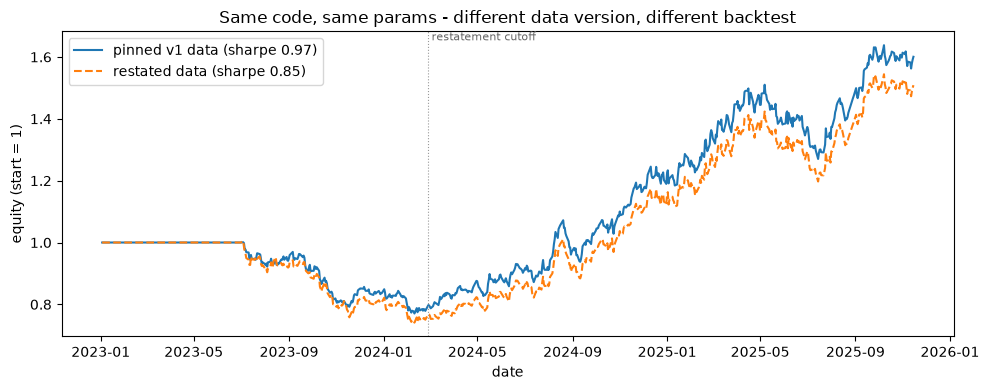

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(run1["curve"].index, run1["curve"], label=f"pinned v1 data (sharpe {run1['sharpe']:.2f})")
ax.plot(run2["curve"].index, run2["curve"], label=f"restated data (sharpe {run2['sharpe']:.2f})",
        ls="--")
ax.axvline(pd.Timestamp(cutoff), color="0.6", lw=0.8, ls=":")
ax.annotate(" restatement cutoff", xy=(pd.Timestamp(cutoff), ax.get_ylim()[1]),
            fontsize=8, va="top", color="0.4")
ax.set_title("Same code, same params - different data version, different backtest")
ax.set_xlabel("date")
ax.set_ylabel("equity (start = 1)")
ax.legend()
fig.tight_layout()

## 6. The pinned re-run is bit-identical, asserted

Now re-run against the snapshot taken before the restatement.

The result is not "close" and not "within tolerance". The SHA-256 of the
equity curve's raw float64 bytes matches, because the inputs are the same
immutable segments.

In [9]:
run3 = run_backtest(snapshot="bt-run-001")

assert run3["sha256"] == run1["sha256"], "pinned re-run must be bit-identical"
assert np.array_equal(run3["curve"].to_numpy(), run1["curve"].to_numpy())
print(f"re-run on 'bt-run-001': sharpe={run3['sharpe']:.6f}")
print(f"curve sha256 identical: {run3['sha256'][:32]}... == {run1['sha256'][:32]}...")
print("bit-identical: PASS")

re-run on 'bt-run-001': sharpe=0.973911
curve sha256 identical: 8835f419a0b862a7f72028c73b52e050... == 8835f419a0b862a7f72028c73b52e050...
bit-identical: PASS


## 7. A minimal run registry

Make the pin discoverable. A `runs` table records the run id, read point,
params as JSON, Sharpe, and the result digest.

Any run in the registry can be reproduced exactly by anyone with the database
directory, because the snapshot name in the row *is* the data dependency.

In [10]:
runs_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("run_id", pa.string()),
        pa.field("read_point", pa.string()),
        pa.field("params", pa.string()),
        pa.field("sharpe", pa.float64()),
        pa.field("curve_sha256", pa.string()),
    ]
)
db.create_table("runs", runs_schema, time_column="ts")

params = json.dumps({"strategy": "momentum", "lookback": 126, "top_n": 5, "universe": 20})
for run_id, read_point, res in [
    ("bt-run-001", "snapshot bt-run-001", run1),
    ("bt-run-001-naive-rerun", "prices (live head)", run2),
    ("bt-run-001-verify", "snapshot bt-run-001", run3),
]:
    row = pa.table(
        {
            "ts": pa.array([pd.Timestamp.now(tz="UTC")], type=pa.timestamp("us", tz="UTC")),
            "run_id": [run_id],
            "read_point": [read_point],
            "params": [params],
            "sharpe": [res["sharpe"]],
            "curve_sha256": [res["sha256"]],
        }
    )
    db.append("runs", row, note=f"register {run_id}")

(
    db.table("runs")
    .select(
        "run_id", "read_point",
        sharpe=col("sharpe").round(4),
        digest=sql_expr("substr(curve_sha256, 1, 12)"),
    )
    .sort("ts")
    .to_pandas()
)

,run_id,read_point,sharpe,digest
0,bt-run-001,snapshot bt-run-001,0.9739,8835f419a0b8
1,bt-run-001-naive-rerun,prices (live head),0.8548,b8a42fbbe659
2,bt-run-001-verify,snapshot bt-run-001,0.9739,8835f419a0b8


## Takeaways

- Backtests should take a **read point**, not a table name. Use the live head
  for exploration and `h5i('prices', '<snapshot>')` for anything you will ever
  have to defend.
- A snapshot is a manifest pin: O(1) to create, zero data copied, immune to
  later restatements. Compare that to the folk remedy of copying CSV extracts
  per run, which costs storage per run, drifts from the source, and cannot be
  queried with SQL.
- Restatements stay loadable the honest way. `write()` with a note creates a
  new version, and the old one remains addressable forever. Data lineage lives
  in `versions()` rather than tribal memory.
- Bit-identical means assertable. Hash the result bytes and let CI verify that
  registered runs still reproduce.

In [11]:
db.close()